In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

/Users/dmitry/Desktop/project/aboba_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/dmitry/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

## EDA

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
def _split_features(df, target):
    """Разбивает колонки на числовые, категориальные и ID-like."""
    numeric = []
    categorical = []
    id_like = []

    for col in df.columns:
        if col == target:
            continue
        nunique = df[col].nunique()
        if pd.api.types.is_numeric_dtype(df[col]) and nunique > 20:
            numeric.append(col)
        elif nunique <= 30:
            categorical.append(col)
        else:
            id_like.append(col)

    return numeric, categorical, id_like

In [12]:
def plot_target_distribution(df, target):
    """Распределение целевой переменной."""
    fig, ax = plt.subplots(figsize=(6, 4))

    counts = df[target].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values)
    for bar in bars:
        val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f"{int(val)}\n({val / len(df) * 100:.1f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_title("Target Distribution")
    ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


In [13]:
def plot_numeric_histograms(df, numeric_cols, target=None):
    """Гистограммы числовых признаков (overlay по target для классификации)."""
    n = len(numeric_cols)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        
        for label in df[target].unique():
            ax.hist(df[df[target] == label][col], bins=30, alpha=0.5,
                    label=str(label), edgecolor="white")
        ax.legend(fontsize=8)
        
        ax.set_title(col)
        ax.set_ylabel("Count")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

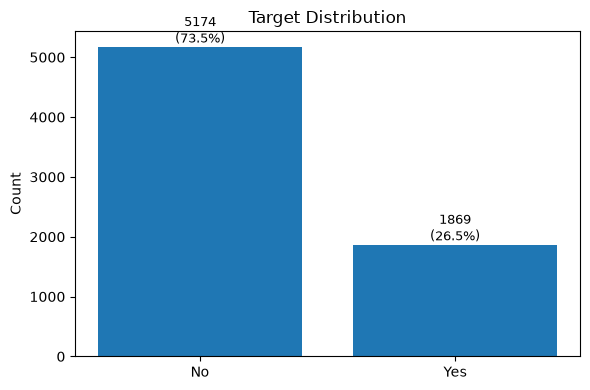

In [14]:
plot_target_distribution(df, target="Churn")

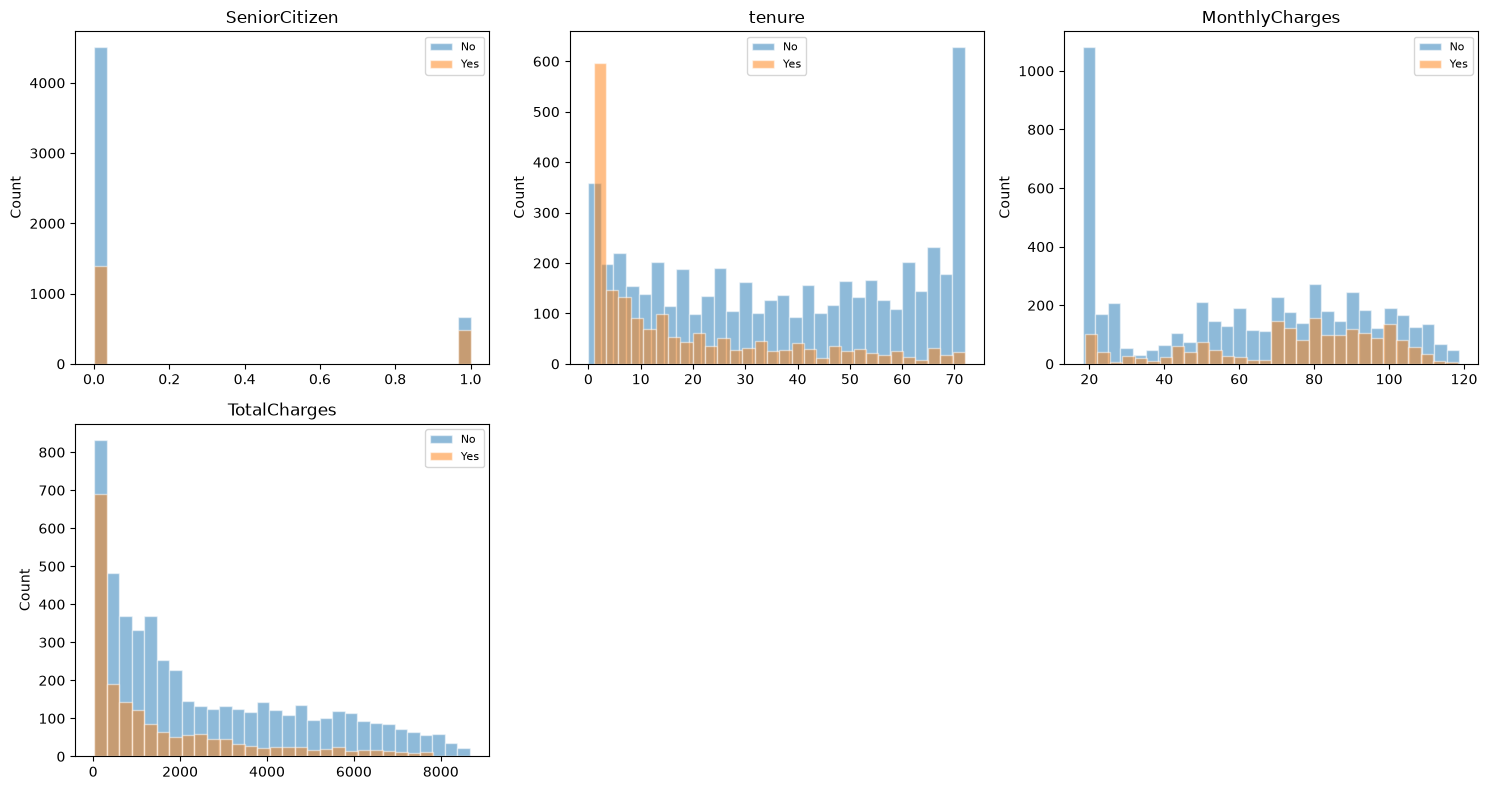

In [15]:
plot_numeric_histograms(df, numeric_cols=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], target="Churn")

In [16]:
def plot_numeric_boxplots(df, numeric_cols, target):
    """Boxplots числовых признаков по target."""
    n = len(numeric_cols)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        sns.boxplot(data=df, x=target, y=col, ax=ax)
        
        ax.set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

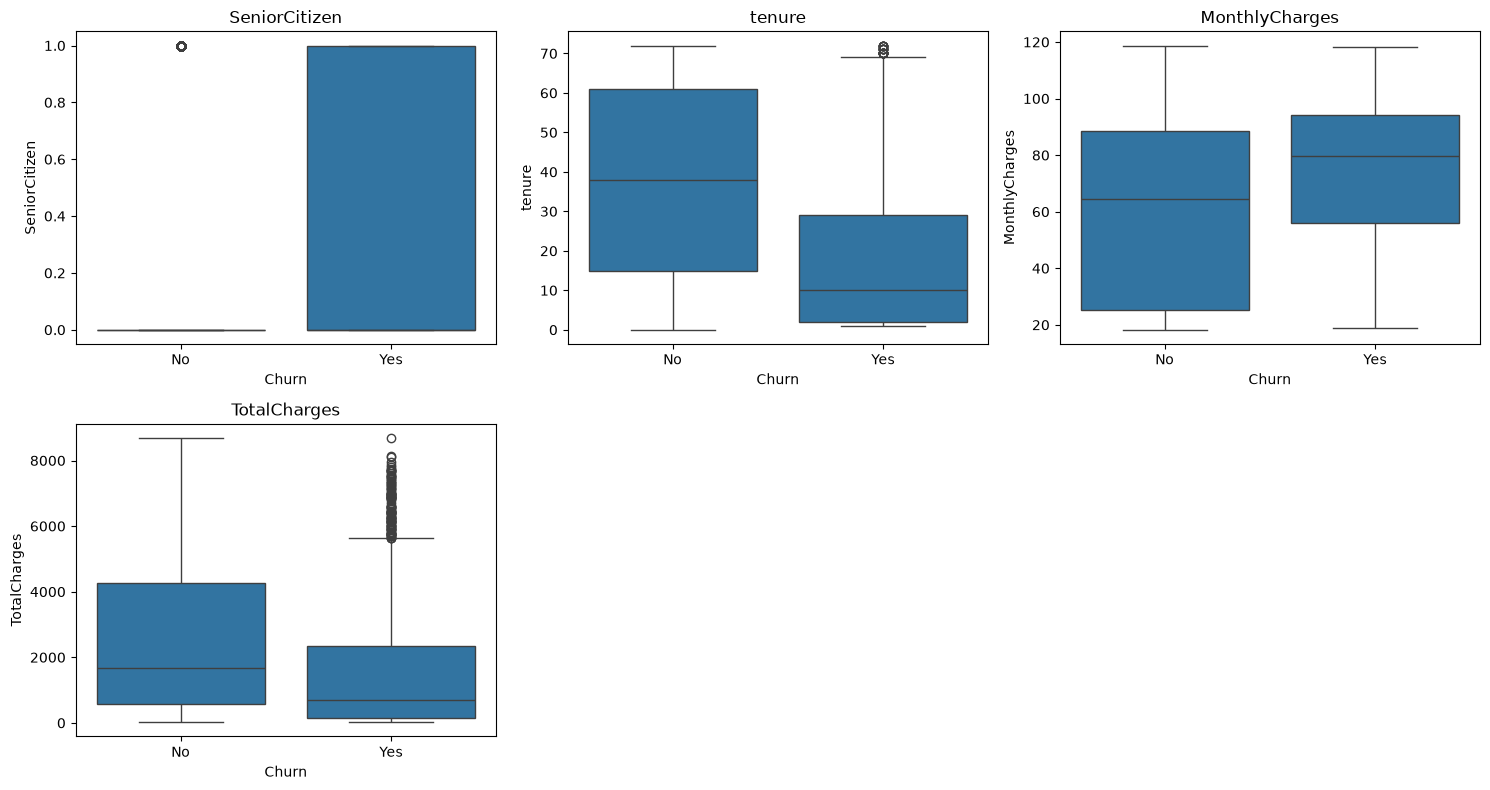

In [17]:
plot_numeric_boxplots(df, numeric_cols=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], target="Churn")

In [18]:
def plot_categorical_counts(df, categorical_cols, top_k=15):
    """Распределение категориальных признаков."""
    n = len(categorical_cols)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        vc = df[col].value_counts().head(top_k)
        ax.barh(vc.index.astype(str), vc.values)
        ax.set_title(col)
        ax.set_xlabel("Count")
        ax.invert_yaxis()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

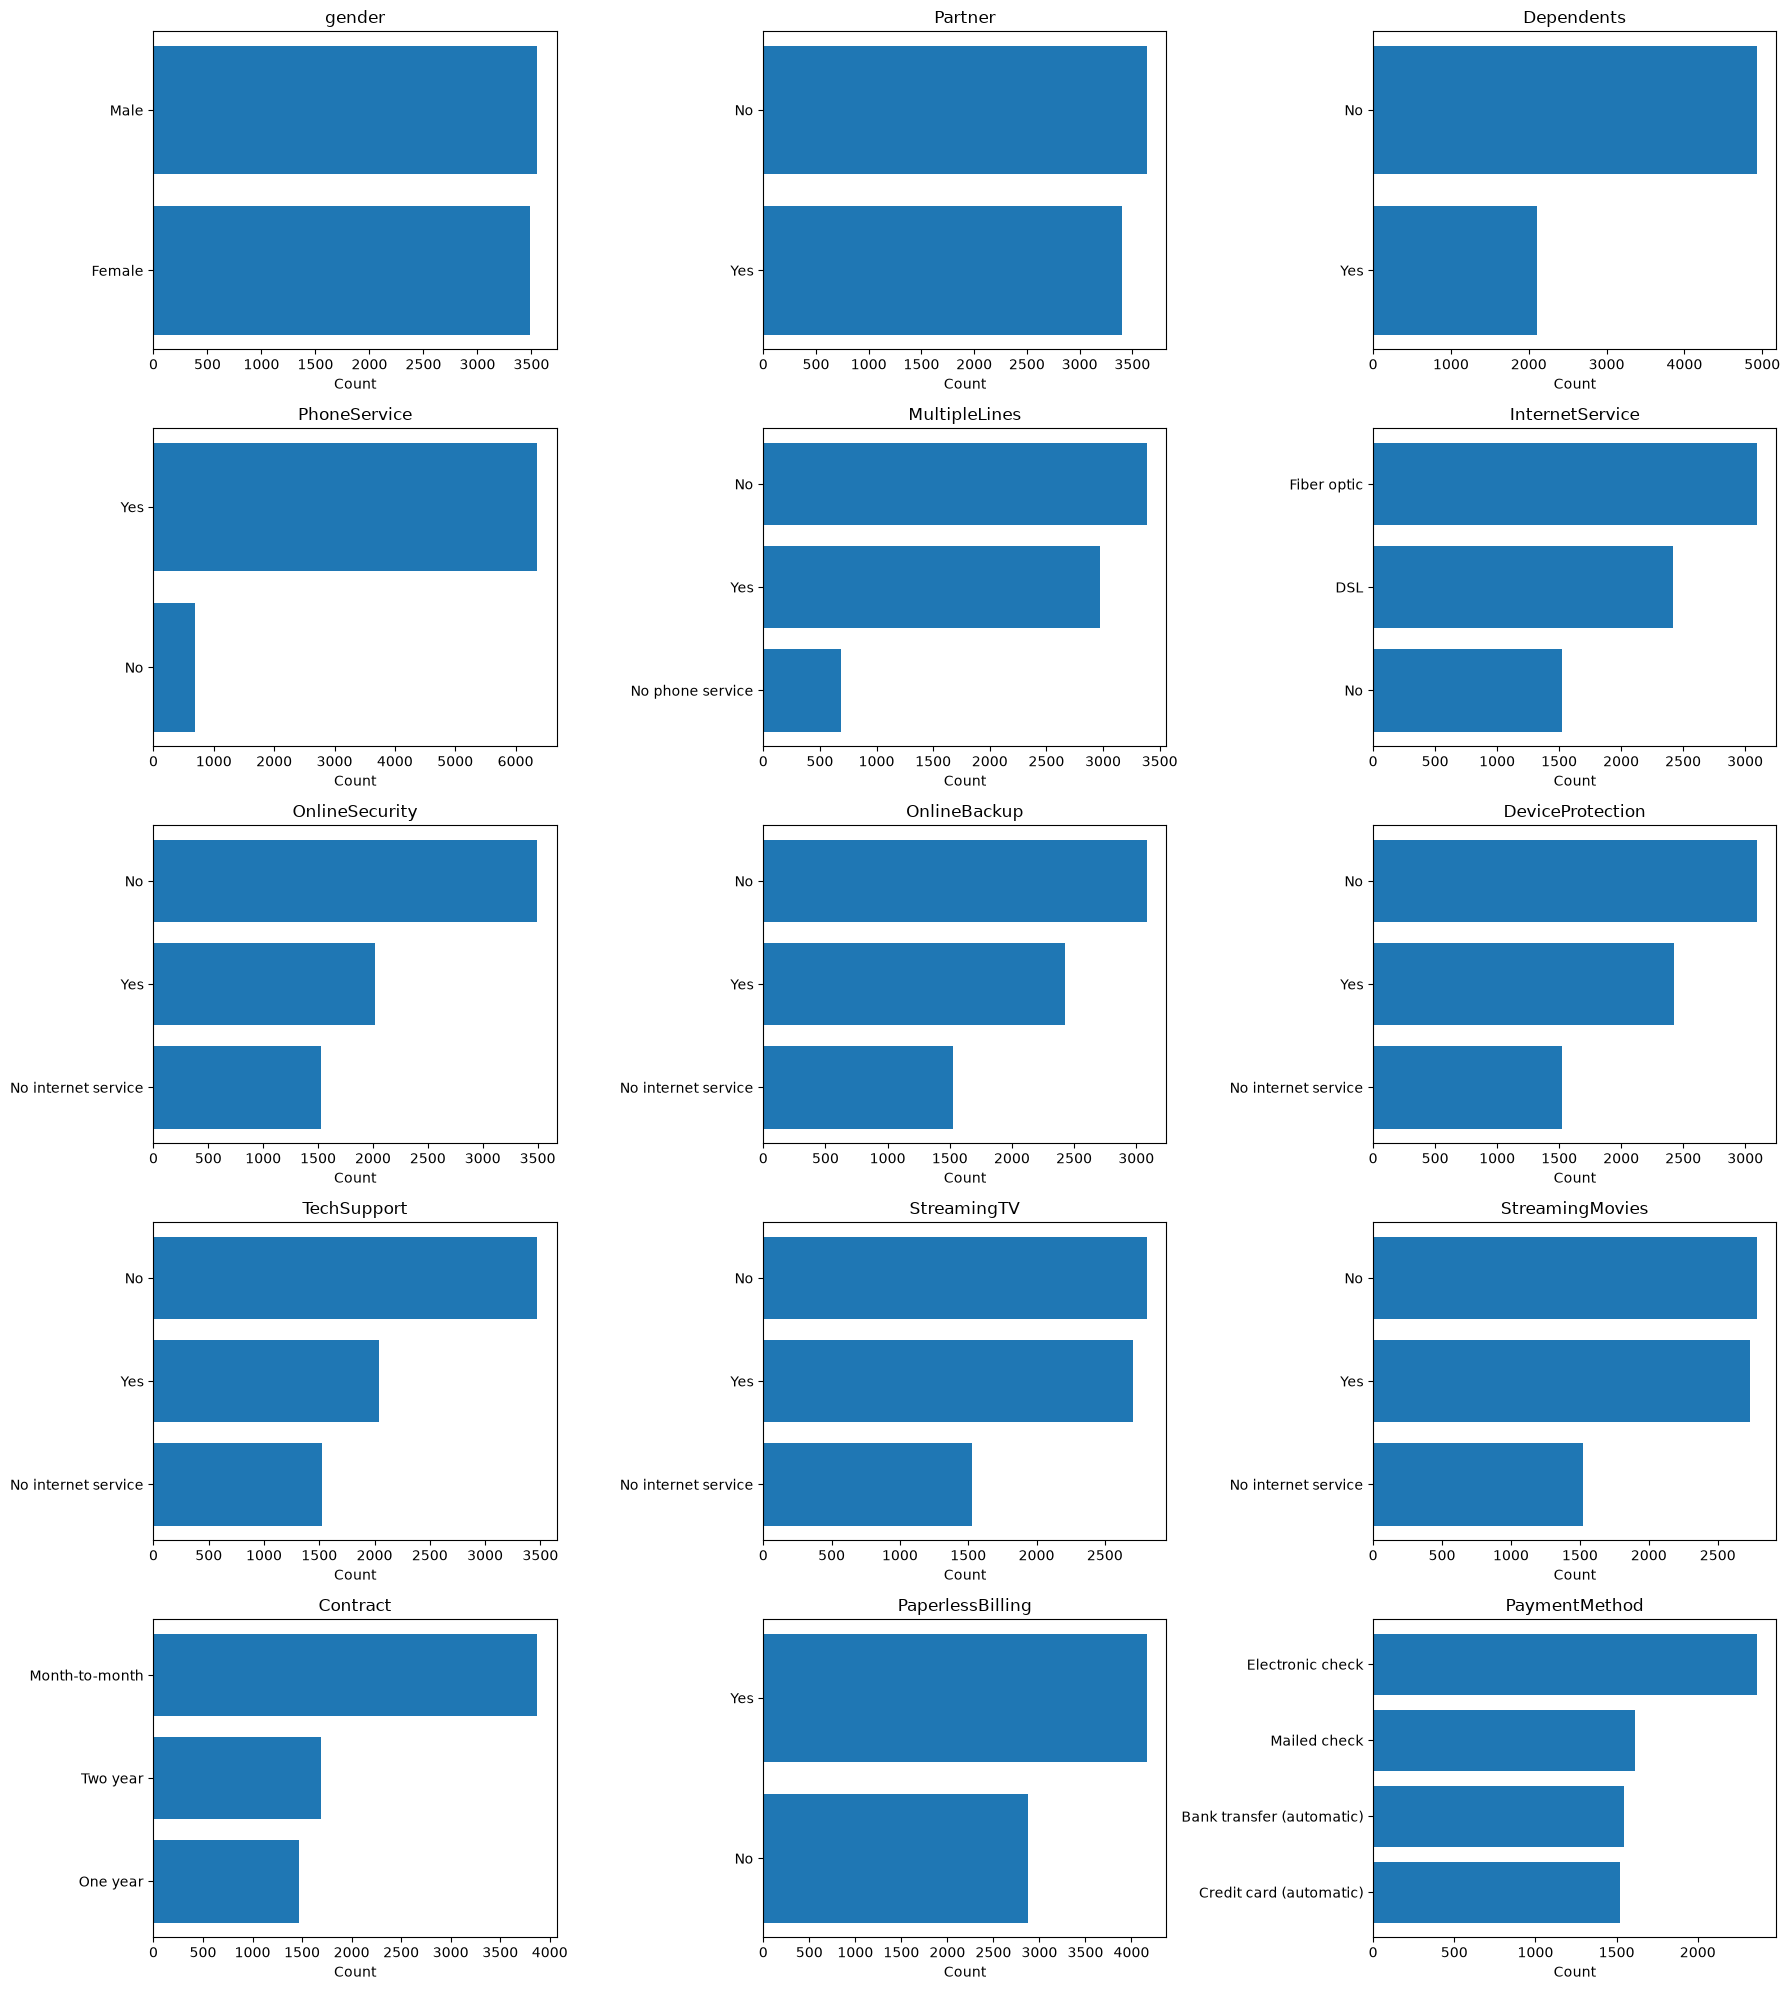

In [19]:
plot_categorical_counts(df, categorical_cols=['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], top_k=10)

In [20]:
def plot_correlation_heatmap(df, numeric_cols, target=None, task="classification"):
    """Корреляции числовых признаков + target."""
    cols = numeric_cols.copy()
    if target:
        
        df = df.copy()
        df[f"{target}_enc"] = (df[target] == df[target].unique()[0]).astype(int)
        cols = cols + [f"{target}_enc"]
        

    corr = df[cols].corr()
    fig, ax = plt.subplots(figsize=(max(8, len(cols) * 0.6), max(6, len(cols) * 0.5)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

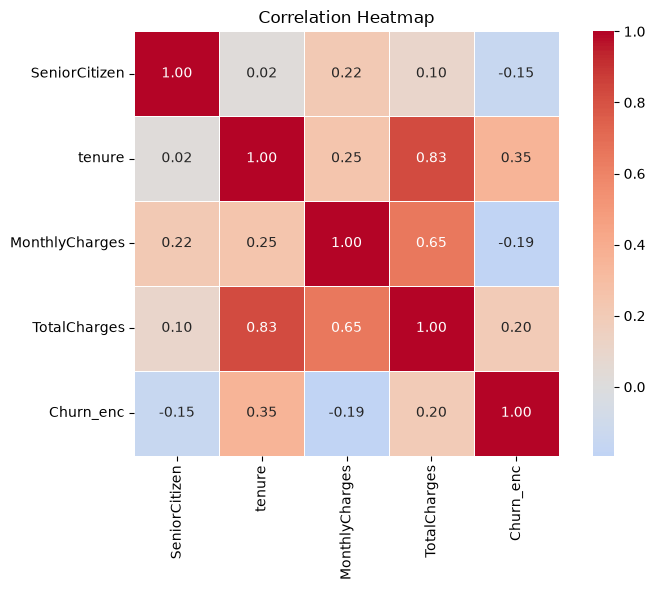

In [21]:
plot_correlation_heatmap(df, numeric_cols=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], target="Churn", task="classification")

In [22]:
def plot_missing_values(df):
    """Пропуски по колонкам."""
    missing = (df.isnull().sum() / len(df) * 100)
    missing = missing[missing > 0].sort_values(ascending=True)

    if missing.empty:
        print("Нет пропусков ✅")
        return

    fig, ax = plt.subplots(figsize=(6, max(4, len(missing) * 0.4)))
    ax.barh(missing.index, missing.values, color="coral")
    ax.set_xlabel("% Missing")
    ax.set_title("Missing Values")
    for i, (col, val) in enumerate(missing.items()):
        ax.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

/var/folders/96/5q60w2vs6sb74wvvssyfl7f00000gn/T/ipykernel_58337/3840781534.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


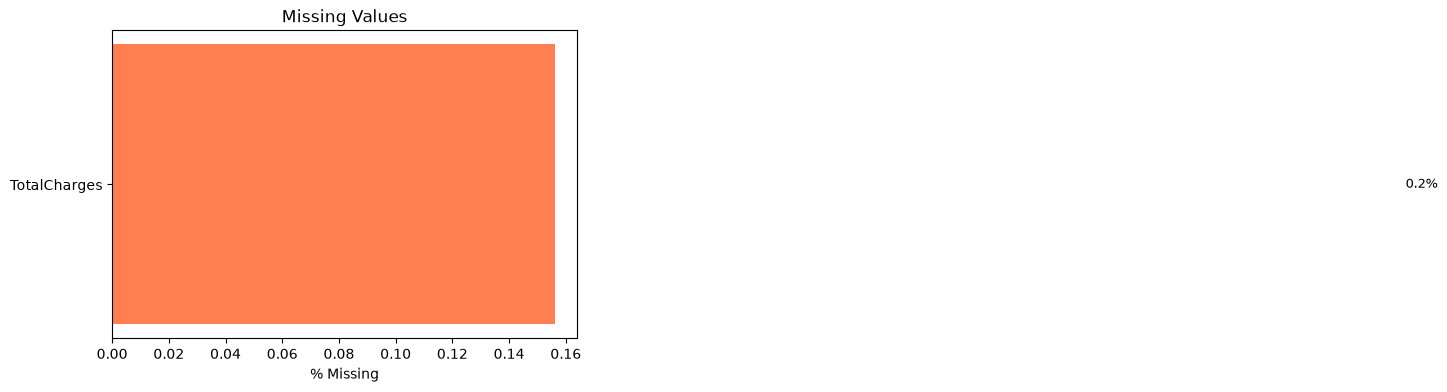

In [23]:
plot_missing_values(df)

In [24]:
def plot_pairplot(df, numeric_cols, target, task="classification", top_k=5):
    """Pairplot топ-k признаков по корреляции с target."""
    if task == "classification":
        df = df.copy()
        df[f"{target}_enc"] = (df[target] == df[target].unique()[0]).astype(int)
        target_enc = f"{target}_enc"
    else:
        target_enc = target

    if len(numeric_cols) <= top_k:
        selected = numeric_cols
    else:
        corrs = df[numeric_cols].corrwith(df[target_enc]).abs().sort_values(ascending=False)
        selected = corrs.head(top_k).index.tolist()

    sns.pairplot(df, vars=selected, hue=target if task == "classification" else None,
                 diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
    plt.show()


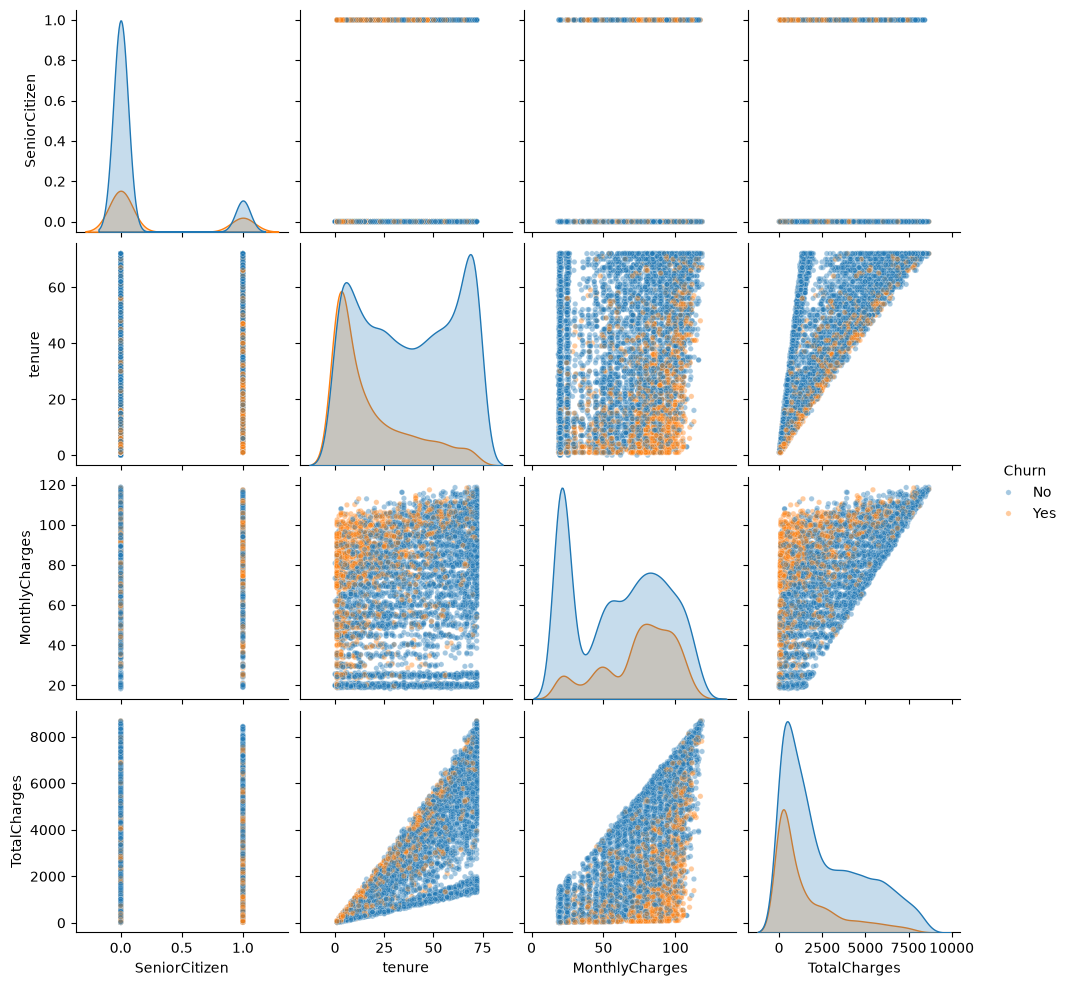

In [25]:
plot_pairplot(df, numeric_cols=['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], target="Churn", task="classification", top_k=4)

## Preprocessing

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

In [27]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

In [28]:
y = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

In [29]:
numeric, categorical, _ = _split_features(df, target="Churn")


In [30]:
numeric, categorical

(['tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [31]:
numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
numeric_transformer = Pipeline(steps=numeric_steps + [("scaler", StandardScaler())])

categorical_steps = [("imputer", SimpleImputer(strategy="most_frequent"))]
categorical_transformer = Pipeline(steps=categorical_steps + [("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric),
        ("cat", categorical_transformer, categorical)
    ]
)


## Fitting

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_recall_curve, auc

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [34]:
baseline_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                    ("classifier", LogisticRegression())])

In [35]:
baseline_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
roc_auc = roc_auc_score(y_test, baseline_pipeline.predict_proba(X_test)[:, 1])
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.8526


In [37]:
accuracy = accuracy_score(y_test, baseline_pipeline.predict(X_test))
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8128


### Cross validation

In [38]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from scipy.stats import randint, uniform, loguniform


In [39]:
PARAMS = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l1", "l2"],
        "model__solver": ["saga"]
    },
    "DecisionTree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__min_samples_split": [2, 10, 20],
    },
     "RandomForest": {
        "model__n_estimators": [100, 200, 500],
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_leaf": [1, 5, 10],
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    },
    "CatBoost": {
        "model__iterations": [200, 500],
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1],
    },
}

In [40]:
models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)    
}

In [41]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
results = []
tuned_pipelines = {}
splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for name, model in models.items():
        grid = PARAMS.get(name)
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])

        search_cv = GridSearchCV(
            pipe,
            grid,
            cv=splitter,
            scoring=scoring,
            refit="f1",
            n_jobs=-1
        )

        search_cv.fit(X_train, y_train)

        # Собираем результаты
        row = {
            "Model": name,
            "Best Params": search_cv.best_params_,
        }
        best_idx = search_cv.best_index_
        cv_results = search_cv.cv_results_
        for metric in scoring:
            key = f"mean_test_{metric}"
            if key in cv_results:
                val = cv_results[key][best_idx]
                if metric.startswith("neg_"):
                    clean = metric.replace("neg_", "").upper()
                    row[clean] = f"{-val:.4f}"
                else:
                    row[metric.upper()] = f"{val:.4f}"

        results.append(row)
        tuned_pipelines[name] = search_cv.best_estimator_
        print(f"✅ {name} — best: {search_cv.best_score_:.4f} (f1_score)")

results_df = pd.DataFrame(results)

/Users/dmitry/Desktop/project/aboba_venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ LogisticRegression — best: 0.5948 (f1_score)
✅ DecisionTree — best: 0.5617 (f1_score)
✅ RandomForest — best: 0.5799 (f1_score)
✅ GradientBoosting — best: 0.5799 (f1_score)
✅ CatBoost — best: 0.5900 (f1_score)


In [42]:
tuned_pipelines['LogisticRegression']

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
tuned_pipelines['CatBoost']

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
results_df.head()

,Model,Best Params,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
0,LogisticRegression,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.8010,0.6483,0.5499,0.5948,0.8433
1,DecisionTree,"{'model__max_depth': 7, 'model__min_samples_le...",0.7794,0.5956,0.5327,0.5617,0.8044
2,RandomForest,"{'model__max_depth': 10, 'model__min_samples_l...",0.7991,0.6522,0.5226,0.5799,0.8397
3,GradientBoosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.8003,0.6566,0.5196,0.5799,0.8450
4,CatBoost,"{'model__depth': 4, 'model__iterations': 200, ...",0.8053,0.6692,0.5279,0.5900,0.8465


In [53]:
best_catboost = tuned_pipelines['CatBoost']

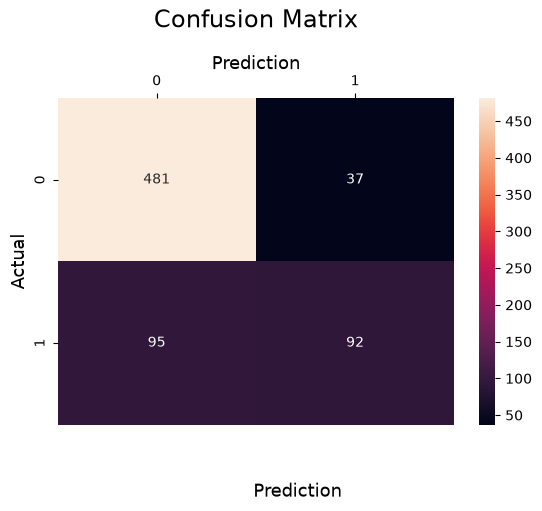

In [56]:
pred = best_catboost.predict(X_test)
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, 
            annot=True,
            fmt='g')
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()


По результатам эксперимента модель CatBoost показала лучший результат среди рассмотренных алгоритмов. Это объясняется тем, что задача предсказания оттока клиентов относится к задачам на табличных данных со смешанными признаками: часть признаков числовая (tenure, MonthlyCharges, TotalCharges), а часть категориальная (Contract, InternetService, PaymentMethod, gender и др.). CatBoost хорошо подходит именно для таких данных, поскольку эффективно работает с категориальными переменными и автоматически учитывает нелинейные взаимодействия между признаками.

Кроме того, в задаче про churn важны метрики recall и F1, а не только accuracy, потому что классы в данных не сбалансированы. CatBoost, как градиентный бустинг на решающих деревьях, обычно лучше справляется с такими задачами и показывает более устойчивые результаты по precision/recall, а также по ROC-AUC. В ноутбуке модель выбиралась по F1-score через GridSearchCV, и CatBoost показала наилучшие результаты по этому критерию.

Логистическая регрессия выступила в роли baseline и показала приемлемый результат, но она менее гибка в моделировании сложных зависимостей между признаками. Деревья и random forest также демонстрируют хорошие показатели, однако CatBoost оказался наиболее эффективным благодаря способности лучше захватывать структуру данных и взаимодействия между факторами, влияющими на уход клиента.

Таким образом, основной вывод состоит в том, что CatBoost оказался лучшей моделью не случайно: она лучше всего подходит для задач churn prediction на смешанных табличных данных с неравномерным распределением классов и сложными взаимодействиями признаков.